# **Distribuição Normal no Mercado Financeiro**

Este código tem como objetivo verificar se os **retornos de um ativo financeiro** seguem uma **distribuição normal**, hipótese comum em modelos financeiros clássicos (como CAPM e Black-Scholes).

## 📊 Metodologia

- Utilizamos  os últimos `n` retornos.
  - Calculamos a **frequência observada** de retornos em cada bin.
  - Estimamos a **frequência esperada**, assumindo que os retornos seguem uma distribuição **normal** com média e desvio padrão amostrais.
- Aplicamos o **teste do qui-quadrado de aderência**, que verifica se a distribuição observada difere significativamente da distribuição esperada.

## 📌 Sobre o teste qui-quadrado

O **teste qui-quadrado de aderência**  é utilizado para avaliar se os dados observados seguem uma distribuição teórica especificada.  
Neste caso, testamos:

- **H₀ (hipótese nula):** os retornos seguem uma distribuição normal.
- **H₁ (hipótese alternativa):** os retornos **não** seguem uma distribuição normal.

Se a estatística do teste ultrapassar o **valor crítico** (ou se o **p-valor < α**, por exemplo 0.05), rejeitamos a hipótese de normalidade.

---

💡 Essa análise é especialmente útil para validar suposições estatísticas antes de aplicar modelos financeiros ou testes baseados na normalidade dos dados.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import chi2
from curl_cffi import requests

import yfinance as yf

import warnings
warnings.filterwarnings("ignore")

In [30]:

# Baixando os dados
TICKER = '^GSPC'  # Exemplo de ticker
start_date = '2023-01-01'
end_date = '2026-01-01'


# Create a session that impersonates a browser
session = requests.Session(impersonate="safari15_5")  # Or "chrome120", etc.

try:
    ticker_obj = yf.Ticker(TICKER, session=session)
    ticker_data = ticker_obj.history(start= start_date, end= end_date, interval='1d')
    df = pd.DataFrame(ticker_data)
    df['Returns'] = df['Close'].pct_change()  # Calculate returns
except Exception as e:
    print(f"Error downloading data: {e}")
    
   
# Excluindo valores NaN
df = df.dropna()


# Exibindo as primeiras linhas do DataFrame
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns
Date,,,,,,,,
2023-01-04 00:00:00-05:00,3840.360107,3873.159912,3815.770020,3852.969971,4414080000,0.0,0.0,0.007539
2023-01-05 00:00:00-05:00,3839.739990,3839.739990,3802.419922,3808.100098,3893450000,0.0,0.0,-0.011646
2023-01-06 00:00:00-05:00,3823.370117,3906.189941,3809.560059,3895.080078,3923560000,0.0,0.0,0.022841
2023-01-09 00:00:00-05:00,3910.820068,3950.570068,3890.419922,3892.090088,4311770000,0.0,0.0,-0.000768
2023-01-10 00:00:00-05:00,3888.570068,3919.830078,3877.290039,3919.250000,3851030000,0.0,0.0,0.006978


# Distribuição dos retornos 

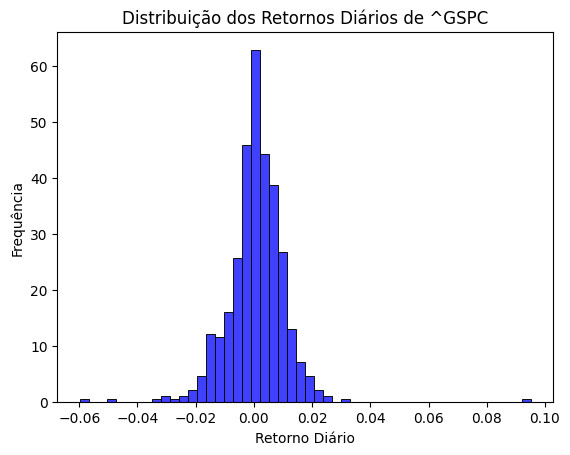

In [31]:
# Distribuição dos retornos

sns.histplot(df['Returns'].dropna(), bins=50, kde=False, color='blue', stat='density')
plt.title(f'Distribuição dos Retornos Diários de {TICKER}')
plt.xlabel('Retorno Diário')
plt.ylabel('Frequência')
plt.show();

# **Teste de Aderência**

### Ho : Os dados são normalmente distribuidos 
### Ha : Os dados não são normalmente distribuidos

In [32]:
# Pegando os retornos diários dos últimos n dias 

n = 90
num_bins = 6 # Número de bins para o histograma(num de intervalos)
ALPHA= 0.01  # nível de significância
df1 = df.tail(n)

In [33]:
# Primeiro iremos dividir os retornos em bins (intervalos) e contar quantos retornos caem em cada bin
observed_freq, bin_edges= np.histogram(df1['Returns'].dropna(), bins=num_bins)

# Agora, vamos calcular a frequência esperada assumindo que os retornos seguem uma distribuição normal
mean = round(df1['Returns'].mean(),2)  
std_dev = round(df1['Returns'].std(),2)
n = len(df1['Returns'].dropna())

# Calculando a densidade de probabilidade para cada bin
z = (bin_edges -   mean) / std_dev

# Calculando a probabilidade acumulada para cada z 
# Calculando a probabilidade acumulada entre os limites de cada bin
cdf_values = norm.cdf(bin_edges, loc=mean, scale=std_dev)
probabilities = np.diff(cdf_values)  # probabilidade de cair em cada bin


freq_esperada = n*probabilities  # multiplicando pela quantidade total de retornos para obter a frequência esperada

# Agora, vamos realizar o teste qui-quadrado
chi2_statistic = np.sum((observed_freq - freq_esperada)**2 / freq_esperada)
df_qui2 = len(bin_edges) - 2  -1  # graus de liberdade: número de bins - 2 - número de parâmetros estimados (média e desvio padrão) -1 
chi2_crit =  chi2.ppf(1 - ALPHA, df_qui2) # valor crítico do qui-quadrado

In [34]:
#tabela de frequência e frequência esperada por intervalo 
freq_table = pd.DataFrame({
    'Bin': [f'[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f})' for i in range(len(bin_edges)-1)],
    'Frequência Observada': observed_freq,
    'Frequência Esperada': freq_esperada
})
freq_table

,Bin,Frequência Observada,Frequência Esperada
0,"[-0.06, -0.03)",3,3.913022
1,"[-0.03, -0.01)",8,26.781898
2,"[-0.01, 0.02)",73,42.254044
3,"[0.02, 0.04)",5,15.594366
4,"[0.04, 0.07)",0,1.306392
5,"[0.07, 0.10)",1,0.023610


In [35]:
print(f'Teste de Aderência Qui-Quadrado para {TICKER}')
print('-'*30)
print(f'Logo, com base no teste Qui-Quadrado(χ2) e alpha igual a {ALPHA}, podemos concluir que:')
print()

if chi2_statistic > chi2_crit:
    print(f"Rejeitamos a hipótese nula: os retornos dos últimos {n} dias não seguem uma distribuição normal (Qui-Quadrado = {chi2_statistic:.2f}, crítico = {chi2_crit:.2f})")   
else:
    print(f"Não rejeitamos a hipótese nula: os retornos dos últimos {n} dias seguem uma distribuição normal (Qui-Quadrado = {chi2_statistic:.2f}, crítico = {chi2_crit:.2f})")

Teste de Aderência Qui-Quadrado para ^GSPC
------------------------------
Logo, com base no teste Qui-Quadrado(χ2) e alpha igual a 0.01, podemos concluir que:

Rejeitamos a hipótese nula: os retornos dos últimos 90 dias não seguem uma distribuição normal (Qui-Quadrado = 84.64, crítico = 13.28)
